# Segmentation de clients avec K-Means

Ce projet a pour objectif de segmenter les clients d’un centre commercial à partir du dataset Mall Customers.  
L’approche utilisée est le clustering non supervisé avec l’algorithme K-Means.

Les variables principales utilisées pour le clustering sont :

- `Annual_Income` : revenu annuel du client ;
- `Spending_Score` : score de dépense attribué au client.

Le projet suit les étapes suivantes :

1. Chargement des données ;
2. Analyse exploratoire ;
3. Nettoyage et préparation ;
4. Normalisation des variables ;
5. Choix du nombre de clusters avec la méthode du coude ;
6. Entraînement du modèle K-Means ;
7. Interprétation des clusters ;
8. Évaluation avec le score de silhouette.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [61]:
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv"

data_dir = Path("data")

data_dir.mkdir(exist_ok=True)

csv_path = data_dir / "Mall_Customers.csv"

df = pd.read_csv(url)

df.to_csv(csv_path, index=False)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [62]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [64]:
df.shape

(200, 5)

In [65]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [66]:
df.duplicated().sum()

np.int64(0)

In [101]:
numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Colonnes numériques :", list(numeric_cols))
print("Colonnes catégorielles :", list(categorical_cols))

Colonnes numériques : ['CustomerID', 'Age', 'Annual_Income', 'Spending_Score', 'Cluster']
Colonnes catégorielles : ['Gender', 'Cluster_Name']


In [68]:
df = df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
})

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


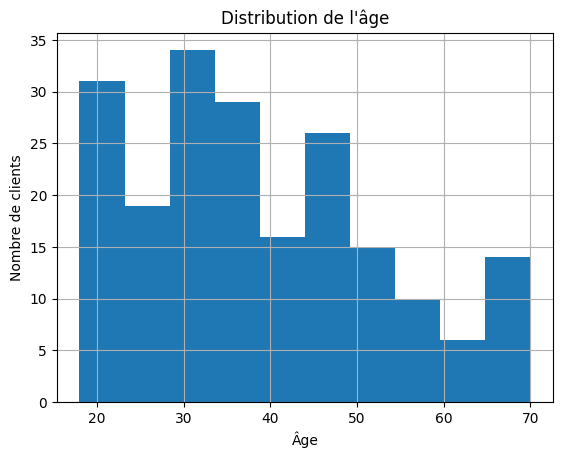

In [69]:
df["Age"].hist()
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")
plt.show()

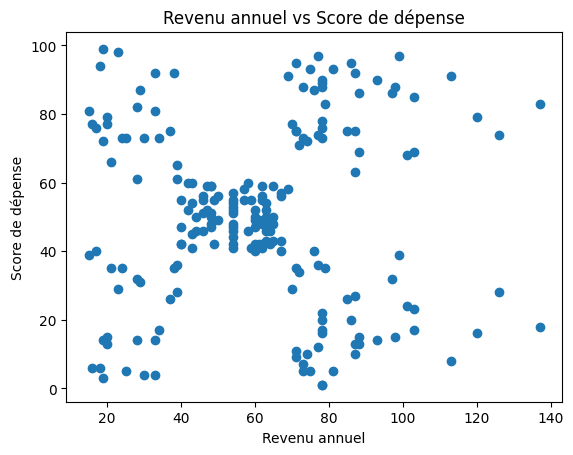

In [70]:
plt.scatter(df["Annual_Income"], df["Spending_Score"])
plt.title("Revenu annuel vs Score de dépense")
plt.xlabel("Revenu annuel")
plt.ylabel("Score de dépense")
plt.show()

In [71]:
gender_counts = df["Gender"].value_counts()

gender_percent = df["Gender"].value_counts(normalize=True) * 100

gender_summary = pd.DataFrame({
    "Nombre": gender_counts,
    "Pourcentage": gender_percent
})

gender_summary

,Nombre,Pourcentage
Gender,,
Female,112,56.0
Male,88,44.0


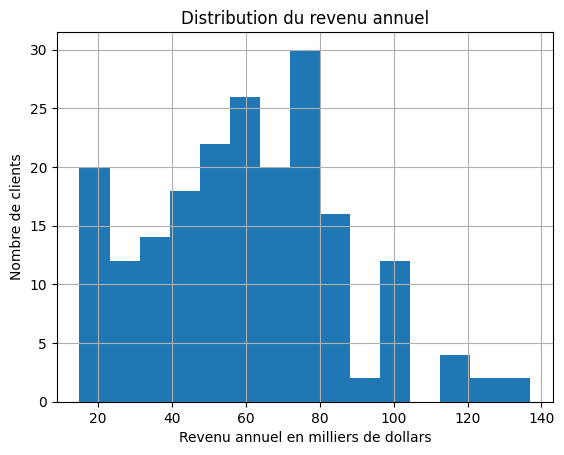

In [72]:
df["Annual_Income"].hist(bins=15)

plt.title("Distribution du revenu annuel")

plt.xlabel("Revenu annuel en milliers de dollars")

plt.ylabel("Nombre de clients")

plt.show()

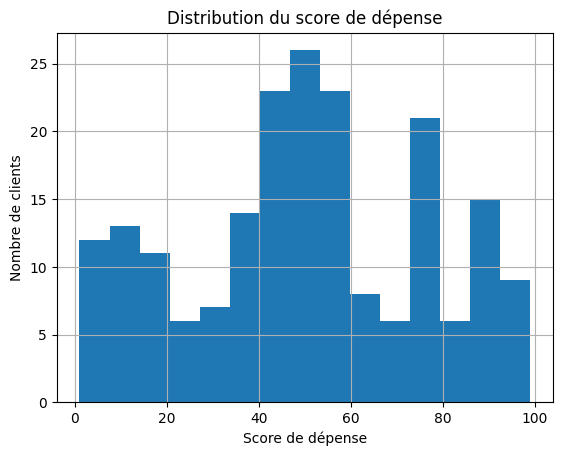

In [73]:
df["Spending_Score"].hist(bins=15)

plt.title("Distribution du score de dépense")

plt.xlabel("Score de dépense")

plt.ylabel("Nombre de clients")

plt.show()

In [74]:
numeric_features = df[["Age", "Annual_Income", "Spending_Score"]]

correlation_matrix = numeric_features.corr()

correlation_matrix

,Age,Annual_Income,Spending_Score
Age,1.000000,-0.012398,-0.327227
Annual_Income,-0.012398,1.000000,0.009903
Spending_Score,-0.327227,0.009903,1.000000


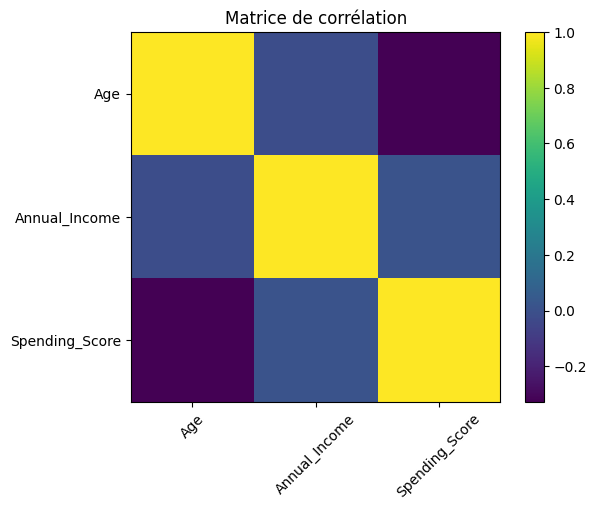

In [75]:
plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)

plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Matrice de corrélation")

plt.show()

In [76]:
features = df[["Annual_Income", "Spending_Score"]]

features.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


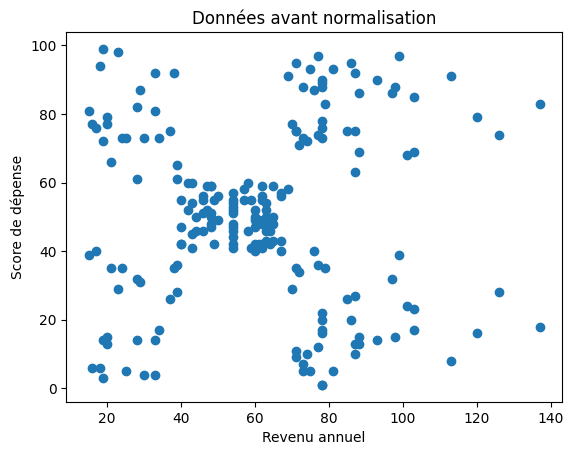

In [77]:
plt.scatter(features["Annual_Income"], features["Spending_Score"])

plt.title("Données avant normalisation")

plt.xlabel("Revenu annuel")

plt.ylabel("Score de dépense")

plt.show()

In [81]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=["Annual_Income_scaled", "Spending_Score_scaled"]
)

features_scaled_df.head()

,Annual_Income_scaled,Spending_Score_scaled
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [82]:
features_scaled_df.describe()

,Annual_Income_scaled,Spending_Score_scaled
count,2.000000e+02,2.000000e+02
mean,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00
min,-1.738999e+00,-1.910021e+00
25%,-7.275093e-01,-5.997931e-01
50%,3.587926e-02,-7.764312e-03
75%,6.656748e-01,8.851316e-01
max,2.917671e+00,1.894492e+00


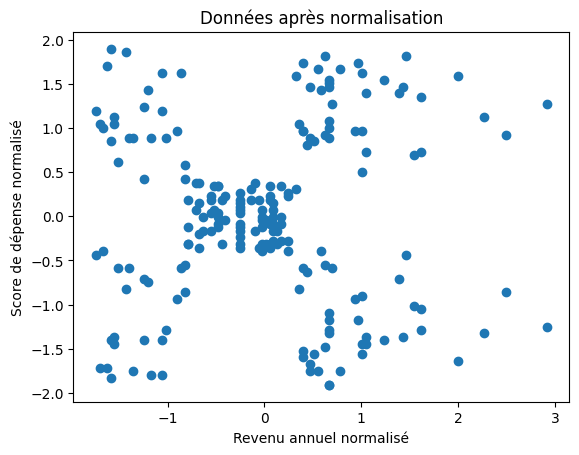

In [83]:
plt.scatter(
    features_scaled_df["Annual_Income_scaled"],
    features_scaled_df["Spending_Score_scaled"]
)

plt.title("Données après normalisation")

plt.xlabel("Revenu annuel normalisé")

plt.ylabel("Score de dépense normalisé")

plt.show()

In [86]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled_df)
    inertias.append(kmeans.inertia_)

In [87]:
inertia_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias
})

inertia_df

,k,inertia
0,1,400.000000
1,2,269.691012
2,3,157.704008
3,4,108.921317
4,5,65.568408
5,6,55.057348
6,7,44.864756
7,8,37.228188
8,9,32.392268
9,10,29.981898


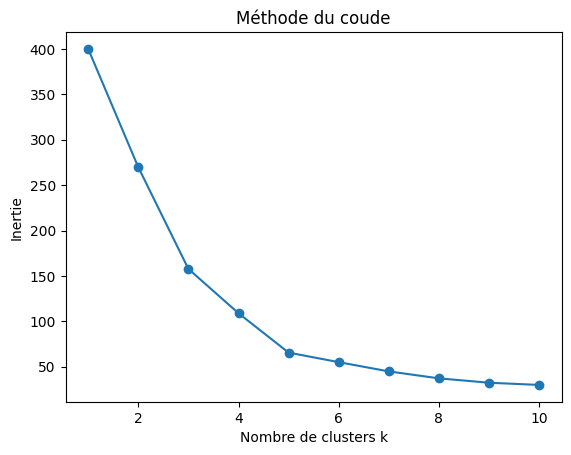

In [88]:
plt.plot(k_values, inertias, marker="o")

plt.title("Méthode du coude")

plt.xlabel("Nombre de clusters k")

plt.ylabel("Inertie")

plt.show()

In [89]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)

La méthode du coude montre une forte diminution de l'inertie jusqu'à k = 5. Après cette valeur, la baisse devient beaucoup plus faible. On choisit donc 5 clusters pour entraîner le modèle K-Means final. Les clusters obtenus permettent de segmenter les clients selon leur revenu annuel et leur score de dépense.

In [90]:
cluster_labels = kmeans_final.fit_predict(features_scaled_df)

In [91]:
df["Cluster"] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [92]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


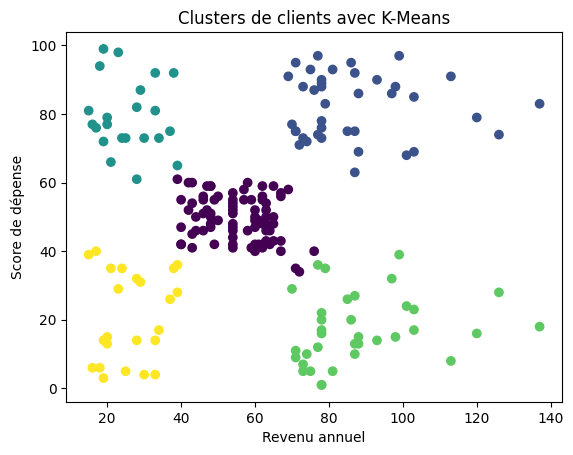

In [93]:
plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

plt.title("Clusters de clients avec K-Means")

plt.xlabel("Revenu annuel")

plt.ylabel("Score de dépense")

plt.show()

In [94]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual_Income", "Spending_Score"]].mean()

cluster_summary = cluster_summary.round(2)

cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_summary["Nombre_clients"] = cluster_counts

cluster_summary

,Age,Annual_Income,Spending_Score,Nombre_clients
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


In [95]:
centroids_scaled = kmeans_final.cluster_centers_

centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=["Annual_Income", "Spending_Score"]
)

centroids_df

,Annual_Income,Spending_Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


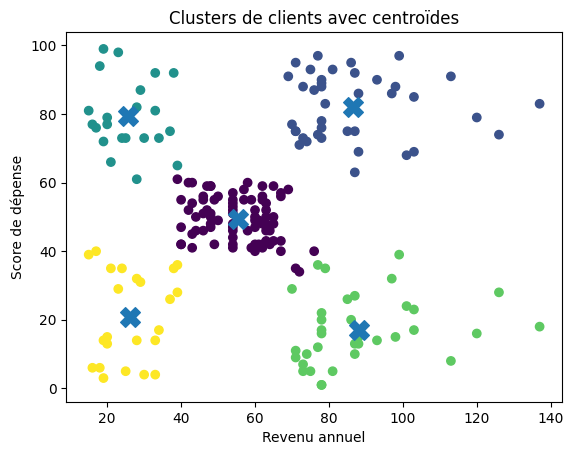

In [96]:
plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

plt.scatter(
    centroids_df["Annual_Income"],
    centroids_df["Spending_Score"],
    marker="X",
    s=200
)

plt.title("Clusters de clients avec centroïdes")

plt.xlabel("Revenu annuel")

plt.ylabel("Score de dépense")

plt.show()

In [97]:
cluster_names = {
    0: "Clients standards / équilibrés",
    1: "Clients premium à forte valeur",
    2: "Jeunes dépensiers à petit revenu",
    3: "Clients aisés mais prudents",
    4: "Clients économes à faible revenu"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster,Cluster_Name
0,1,Male,19,15,39,4,Clients économes à faible revenu
1,2,Male,21,15,81,2,Jeunes dépensiers à petit revenu
2,3,Female,20,16,6,4,Clients économes à faible revenu
3,4,Female,23,16,77,2,Jeunes dépensiers à petit revenu
4,5,Female,31,17,40,4,Clients économes à faible revenu


Le modèle K-Means avec k = 5 permet d'identifier cinq segments de clients. Le cluster 0 représente les clients standards avec un revenu et un score de dépense moyens. Le cluster 1 regroupe les clients premium, avec revenu élevé et forte dépense. Le cluster 2 correspond à des clients jeunes avec faible revenu mais score de dépense élevé. Le cluster 3 regroupe des clients aisés mais peu dépensiers. Enfin, le cluster 4 correspond aux clients à faible revenu et faible score de dépense. Ces segments peuvent aider à adapter les stratégies marketing selon le profil des clients.

In [98]:
from sklearn.metrics import silhouette_score

silhouette_k5 = silhouette_score(features_scaled_df, df["Cluster"])

silhouette_k5

np.float64(0.5546571631111091)

In [99]:
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled_df)
    score = silhouette_score(features_scaled_df, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


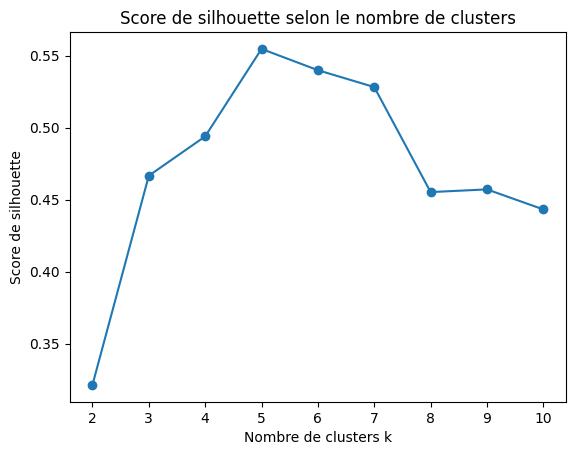

In [100]:
plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Score de silhouette selon le nombre de clusters")

plt.xlabel("Nombre de clusters k")

plt.ylabel("Score de silhouette")

plt.show()

Le score de silhouette a été calculé pour plusieurs valeurs de k, de 2 à 10. Le meilleur score est obtenu pour k = 5, avec une valeur d’environ 0.555. Cela indique que les clusters sont plutôt bien séparés et que les clients sont globalement proches des autres clients de leur propre groupe. Ce résultat confirme le choix de k = 5 déjà suggéré par la méthode du coude. Le modèle K-Means final avec 5 clusters est donc retenu.

## Conclusion du projet

Ce projet avait pour objectif de réaliser une segmentation de clients à partir du dataset **Mall Customers** en utilisant une approche de clustering non supervisée. L'idée principale était d'identifier des groupes de clients ayant des comportements similaires à partir de deux variables principales : le revenu annuel (`Annual_Income`) et le score de dépense (`Spending_Score`).

Dans un premier temps, une analyse exploratoire des données a été réalisée afin de comprendre la structure du dataset. Le jeu de données contient 200 clients et 5 variables : `CustomerID`, `Gender`, `Age`, `Annual_Income` et `Spending_Score`. L'identifiant client (`CustomerID`) n'a pas été utilisé pour le clustering, car il ne contient pas d'information comportementale utile. Les premières analyses ont montré que les variables `Annual_Income` et `Spending_Score` étaient particulièrement intéressantes pour segmenter les clients.

L'analyse de corrélation a montré qu'il n'existait presque pas de relation linéaire globale entre le revenu annuel et le score de dépense. Cependant, l'absence de corrélation ne signifie pas absence de structure. En effet, le nuage de points a révélé plusieurs zones distinctes de clients. Cela illustre une différence importante entre corrélation et clustering : la corrélation cherche une relation linéaire globale entre deux variables, tandis que le clustering cherche des groupes de points proches les uns des autres.

Avant d'appliquer l'algorithme K-Means, les variables sélectionnées ont été normalisées avec `StandardScaler`. Cette étape est importante, car K-Means est basé sur les distances. Sans normalisation, une variable ayant une échelle plus grande pourrait influencer excessivement la formation des clusters.

Le choix du nombre de clusters a été effectué à l'aide de la méthode du coude. L'évolution de l'inertie a montré une forte diminution jusqu'à `k = 5`, puis une baisse beaucoup plus faible après cette valeur. Cela suggère que 5 clusters constituent un bon compromis entre simplicité du modèle et qualité de segmentation.

Un modèle K-Means final a donc été entraîné avec `k = 5`. Les clusters obtenus permettent de distinguer cinq profils de clients :

| Cluster | Profil identifié | Description |
|---|---|---|
| Cluster 0 | Clients standards / équilibrés | Clients ayant un revenu moyen et un score de dépense moyen. C'est le groupe le plus important en nombre de clients. |
| Cluster 1 | Clients premium à forte valeur | Clients ayant un revenu élevé et un score de dépense élevé. Ce groupe représente une cible commerciale très intéressante. |
| Cluster 2 | Jeunes dépensiers à petit revenu | Clients plutôt jeunes, avec un revenu faible mais un score de dépense élevé. |
| Cluster 3 | Clients aisés mais prudents | Clients ayant un revenu élevé mais un faible score de dépense. Ils ont un potentiel commercial, mais sont actuellement peu engagés. |
| Cluster 4 | Clients économes à faible revenu | Clients ayant un faible revenu et un faible score de dépense. |

L'interprétation des clusters montre que le modèle permet de produire une segmentation claire et exploitable d'un point de vue métier. Par exemple, les clients premium pourraient recevoir des offres exclusives, tandis que les clients aisés mais prudents pourraient être ciblés avec des campagnes visant à augmenter leur engagement.

Pour évaluer la qualité du clustering, le score de silhouette a été utilisé. Le score obtenu pour `k = 5` est d'environ **0.555**, ce qui indique une séparation correcte entre les groupes. De plus, la comparaison des scores de silhouette pour plusieurs valeurs de `k` montre que `k = 5` donne le meilleur résultat parmi les valeurs testées. Cette évaluation confirme donc le choix effectué avec la méthode du coude.

En résumé, ce projet a permis de mettre en œuvre un pipeline complet de clustering :

1. Chargement et découverte des données ;
2. Analyse exploratoire ;
3. Sélection des variables pertinentes ;
4. Normalisation des données ;
5. Choix du nombre de clusters avec la méthode du coude ;
6. Entraînement du modèle K-Means ;
7. Interprétation métier des clusters ;
8. Évaluation avec le score de silhouette.

Ce travail montre que le clustering peut être un outil puissant pour segmenter une clientèle sans disposer de variable cible. Il permet de révéler des profils cachés dans les données et d'aider à la prise de décision marketing.

Cependant, cette analyse présente aussi certaines limites. Le clustering a été réalisé uniquement avec deux variables : le revenu annuel et le score de dépense. L'ajout d'autres variables, comme l'âge ou le genre, pourrait permettre d'obtenir une segmentation plus riche. De plus, les noms donnés aux clusters sont des interprétations métier basées sur les moyennes observées ; ils ne représentent pas des catégories officielles.

Pour aller plus loin, il serait possible de comparer K-Means avec d'autres méthodes de clustering comme DBSCAN ou le clustering hiérarchique. Il serait également intéressant d'étudier l'impact de l'ajout de nouvelles variables sur la qualité et l'interprétation des clusters.